# **SEMINAR 1**

In this seminar, you will implement a linear regression algorithm that predicts
the performance of Wi-Fi deployments. For that, you will use a reference dataset
(dataset Seminar1.txt) that contains the simulated Wi-Fi networks along with different parameters. The main purpose of this seminar is twofold: (1) process, visualize,
and understand the target dataset, (2) train and evaluate a linear regression algorithm
using the target dataset.


**PART** **1**

Create a module that processes the data. The main operations your module must do are:

*   Loading the dataset from the .txt file and storing the data in a structured manner.
*   Displaying statistics about each feature (mean, standard deviation).
*   Plotting relevant figures to visualize how data is distributed.
*   Processing the data (e.g., cleaning, normalization, categorical, etc.) and prepare it to be used by an ML model.
*   Splitting the data into different partitions to be used for training (e.g., 80%) and testing (e.g., 20%).

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [22]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


**Loading the dataset from the .txt file and storing the data in a structured manner**

In [23]:
# https://pandas.pydata.org/docs/
path = '/content/drive/Shared drives//ML4N/seminar 1/dataset_Seminar1.txt'

data = pd.read_csv(path, delim_whitespace=True,header=None)
data.columns = [f"feature_{i}" for i in range(data.shape[1])]

data = data.apply(pd.to_numeric)

data.head() #To print the 5 first rows.

/tmp/ipykernel_41641/2865635798.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True,header=None)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
0,40.0,60000000.0,22.0,39.0,858.0,63.0,80.0,4000.0,-42.928330,-63.163012,-74.965338,0.415189,7.208644e+06,1.229466e+07,1.084041,0.875490
1,35.0,52500000.0,20.0,33.0,660.0,31.0,40.0,10000.0,-47.815800,-63.298410,-72.847989,0.485311,1.545116e+07,1.275042e+07,1.111263,0.873785
2,16.0,12000000.0,34.0,14.0,476.0,255.0,40.0,4000.0,-46.138494,-60.076333,-70.044800,0.099413,6.743660e+06,2.251690e+06,0.880036,0.849701
3,37.0,18500000.0,35.0,7.0,245.0,31.0,80.0,10000.0,-42.708813,-60.141393,-72.029643,0.493704,1.675025e+07,1.211374e+07,1.126341,0.860103
4,18.0,4500000.0,36.0,35.0,1260.0,127.0,160.0,8000.0,-45.492991,-63.780783,-76.225550,0.011664,4.500000e+06,1.446000e-03,0.276770,0.275687


**Displaying statistics about each feature (mean, standard deviation)**

In [24]:
print(data.describe().round(2))

       feature_0    feature_1  feature_2  feature_3  feature_4  feature_5  \
count  100000.00    100000.00  100000.00  100000.00  100000.00  100000.00   
mean       21.45  21402920.00      20.56      20.48     421.27     227.04   
std        11.55  18520420.53      11.55      11.54     360.34     323.35   
min         2.00    500000.00       1.00       1.00       1.00       3.00   
25%        11.00   7250000.00      11.00      11.00     120.00      15.00   
50%        21.00  16000000.00      21.00      20.00     320.00      63.00   
75%        31.00  30000000.00      31.00      30.00     640.00     255.00   
max        41.00  82000000.00      40.00      40.00    1600.00    1023.00   

       feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
count  100000.00  100000.00  100000.00  100000.00   100000.00   100000.00   
mean       75.11    7997.58     -45.91     -57.58      -66.47        0.23   
std        53.70    2825.53       5.40       6.11        8.06        0.22  

With this statistics, we can observe some potential columns that may have outliers. To corroborate it, we plot histograms and boxplots for every column.

**Plotting relevant figures to visualize how data is distributed**

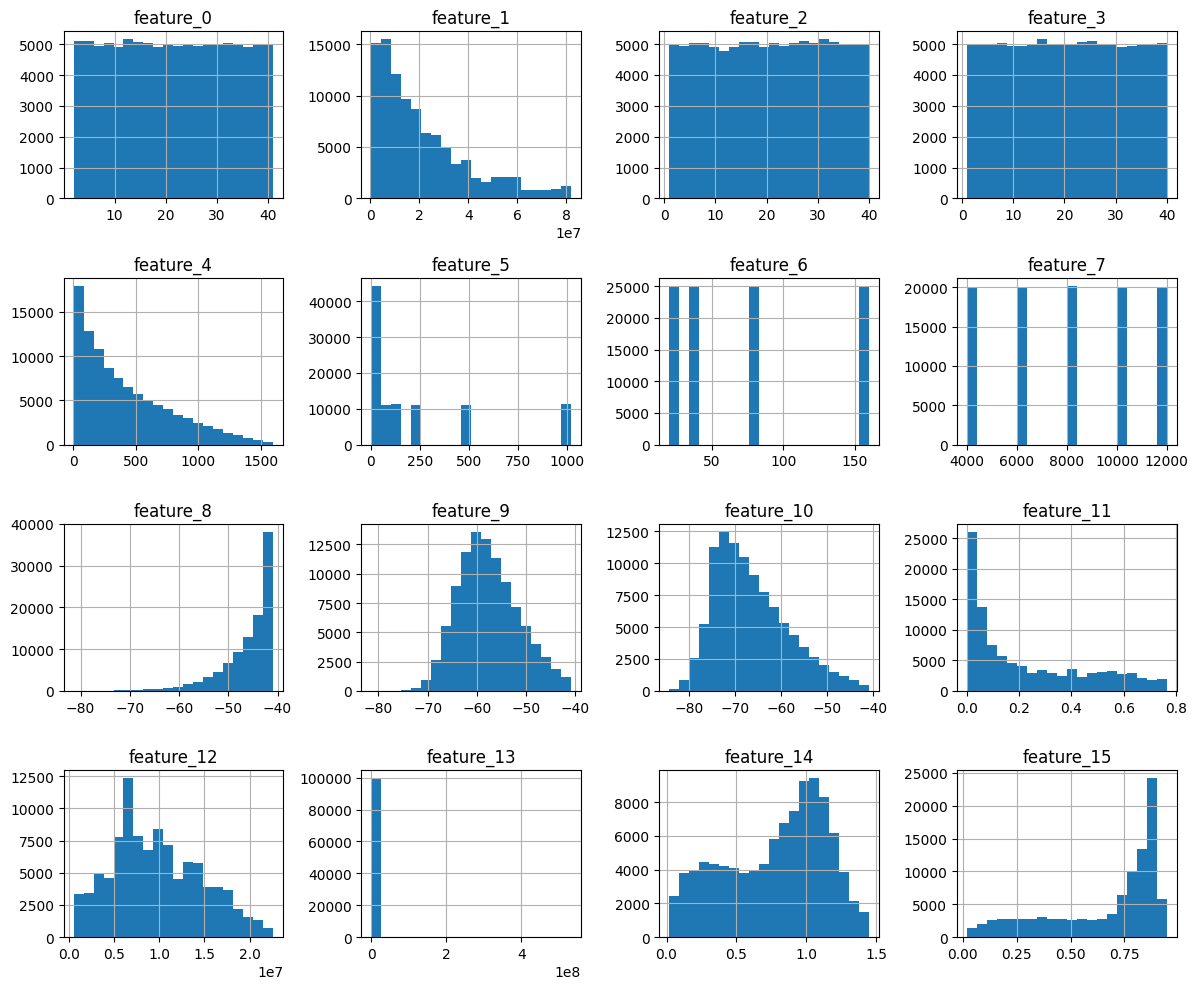

In [25]:
data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

In this histograms we can see many distributions that gives us an intuition of what the data is. We can see distributions where every value appears more or less the same amount of times (feature2 = size(x)). Also we can see skeewed distributions (feature 15 = proportional airtime) and discrete distributions where it only appears some values with the same amount of times (packet size).

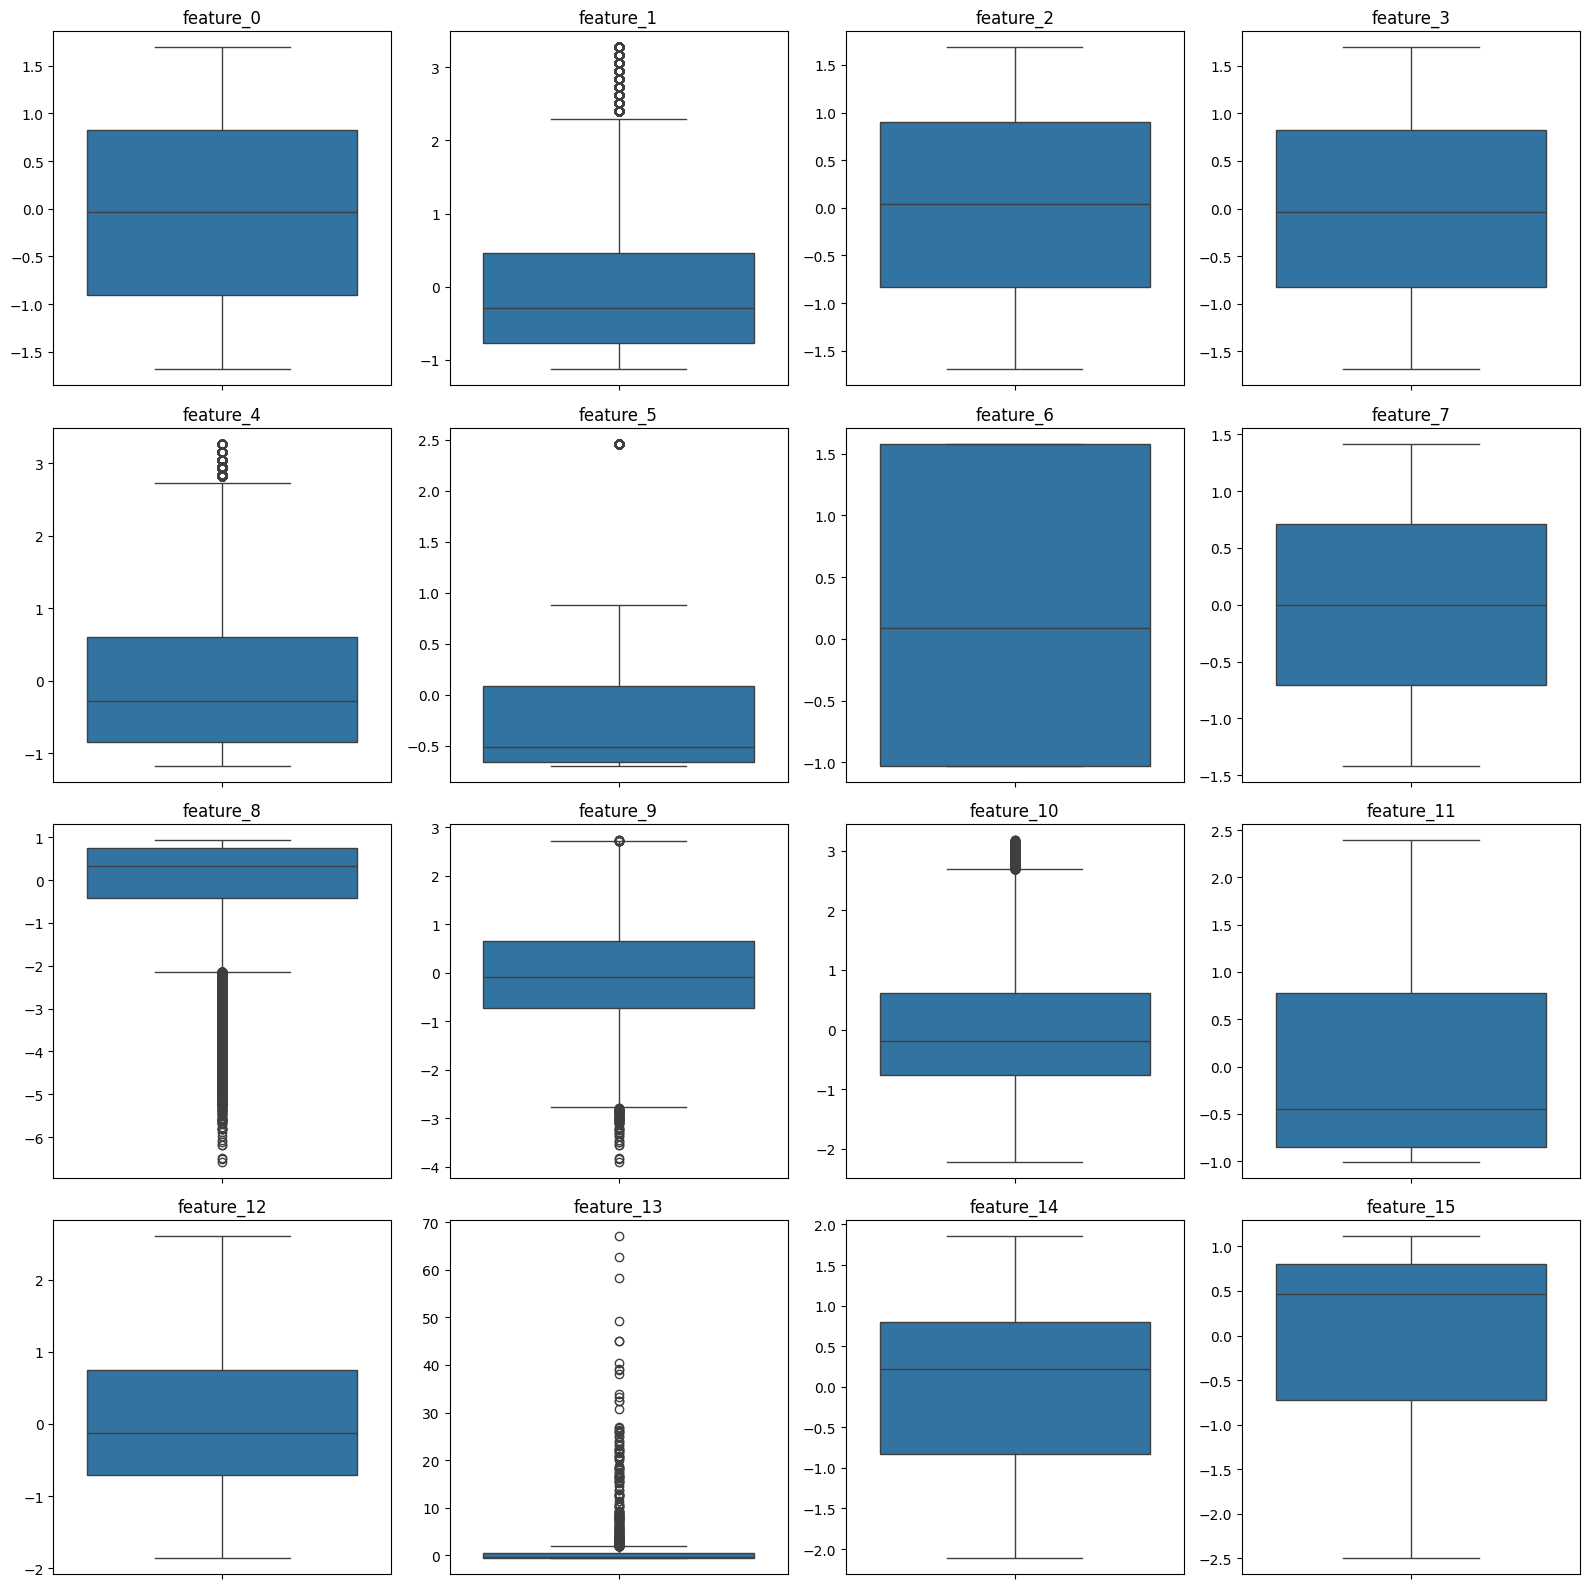

In [26]:
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
# https://stackoverflow.com/questions/46862861/what-does-axes-flat-in-matplotlib-do
# https://seaborn.pydata.org/generated/seaborn.boxplot.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
cols = data_scaled.columns

#Create the grid.
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i in range(len(cols)):
    #BoxPlot
    sns.boxplot(data = data_scaled[cols[i]], ax=axes[i])
    axes[i].set_title(cols[i])
    axes[i].set_ylabel("") #Clear to plot the next one

plt.tight_layout()
plt.show()

This boxplots shows as in a graphical way which columns have outliers thanks to the IQR intervals.

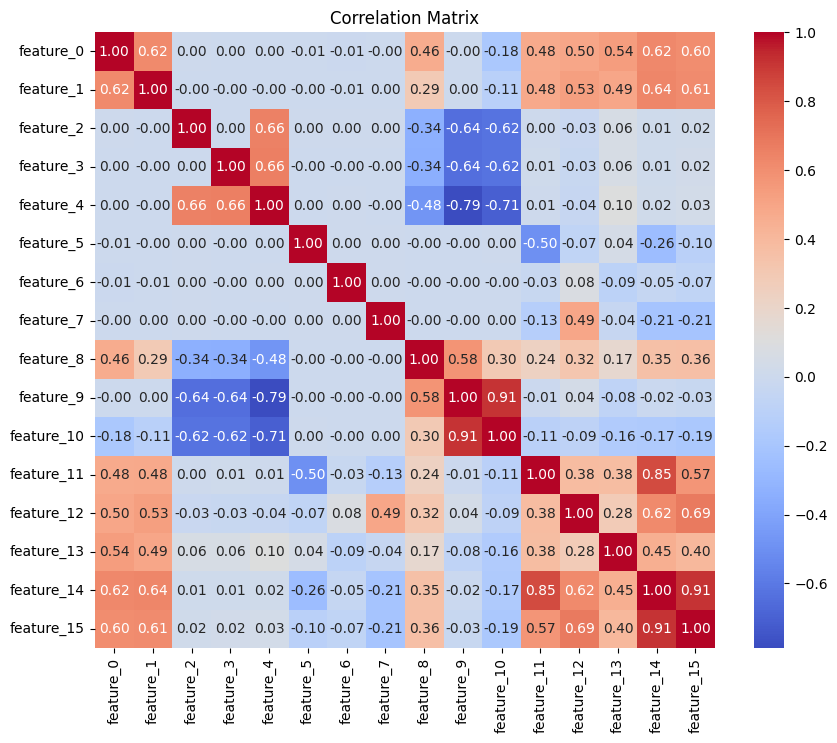

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

This heatmap shows us the correlation between all features, so we can know more about the data. For example, we can see that proportional airtime is really correlated with total airtime.

**Processing the data (e.g., cleaning, normalization, categorical, etc.) and prepare it to be used by an ML model**

In [28]:
for col in data.columns:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers_col = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
  print(f"Outliers in column {col}:")
  print(outliers_col[col])
  data_clean = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)] #removing outliers

#Normalization of the data without outliers
scaler = StandardScaler()
data_norm_cl = pd.DataFrame(scaler.fit_transform(data_clean), columns=data_clean.columns)

Outliers in column feature_0:
Series([], Name: feature_0, dtype: float64)
Outliers in column feature_1:
52       68000000.0
75       68000000.0
93       74000000.0
109      78000000.0
128      68000000.0
            ...    
99948    82000000.0
99968    82000000.0
99990    68000000.0
99994    82000000.0
99995    74000000.0
Name: feature_1, Length: 3749, dtype: float64
Outliers in column feature_2:
Series([], Name: feature_2, dtype: float64)
Outliers in column feature_3:
Series([], Name: feature_3, dtype: float64)
Outliers in column feature_4:
39       1482.0
47       1520.0
174      1444.0
448      1440.0
485      1482.0
          ...  
99369    1440.0
99543    1444.0
99701    1482.0
99834    1600.0
99940    1560.0
Name: feature_4, Length: 975, dtype: float64
Outliers in column feature_5:
7        1023.0
15       1023.0
35       1023.0
44       1023.0
69       1023.0
          ...  
99967    1023.0
99968    1023.0
99970    1023.0
99983    1023.0
99990    1023.0
Name: feature_5, Length: 

**Splitting the data into different partitions to be used for training (e.g., 80%) and testing (e.g., 20%)**

We have to focus on throughput (feature 12)

In [29]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

X = data_norm_cl.iloc[:, 0:11] #Take from feature 0 to feature 10.
Y = data_norm_cl.iloc[:, 12] #Take the freature 12, that is the performance of the wifi.

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

**PART 2**

Create a module that trains and evaluates a linear regression model. The main operations
your module must do are:


*   Fitting the data into an ML model (in this case, a multi-variable linear regression),
i.e., estimating the coefficients of the model.
*   Evaluating the performance of the model using a given error function.
*   Plotting the results visually (e.g., training loss, test accuracy).






**Fitting the data into an ML model (in this case, a multi-variable linear regression), i.e., estimating the coefficients of the model.**



In [30]:
# https://scikit-learn.org/stable/api/sklearn.linear_model.html

model = LinearRegression()
model.fit(X_train, y_train)

print("Coeficients:", model.coef_)
print("Bias:", model.intercept_)

Coeficients: [ 0.16715601  0.3563411  -0.31716536 -0.31769239  0.24718699 -0.07023005
  0.08249437  0.49199277  0.10998218  0.05054049 -0.31631802]
Bias: 0.0005436740593727503


Here we can see that fo example feature 7 = packet size has more impact in the throughput than other since its cofficient is 0.49. This make sense since if the packet size increases there ir more throughput. For example, feature 2 = size(x) has a negative impact in the throughput. The coefficients tell us how throughput changes when a feature increases 1 unit (mantaining the other ones constant).

Also we can see a very small bias that can be aproximated to 0 which means that the data is centered.

**Evaluating the performance of the model using a given error function.**

In [31]:
y_pred = model.predict(X_test) #The model predicts possible outputs of feature 15 with the inputs of the test dataset.

mean_error = mean_squared_error(y_test, y_pred) #Compare the predicions with the actual values from the test dataset to se if the model is correct.
absolut_error = mean_absolute_error(y_test, y_pred)
train_mse = mean_squared_error(y_train, model.predict(X_train))
R2 = model.score(X_test, y_test)

print("R2:", R2)
print("Train MSE:", train_mse)

print("Mean error of the model:", mean_error)
print("Absolute error:", absolut_error)

R2: 0.6008653964105195
Train MSE: 0.4041549084725518
Mean error of the model: 0.39900014823147256
Absolute error: 0.5070575557054203


Here we can observe that the mean error is 0.405 which means that since it is positive, the model tends to subestimate (predicts lower values of throughput than the real ones).

Then, the absolute value is 0.51 which means that on average, our model is wrong by 0.51 units of throughput. This means that is not a really good model.

**Plotting the results visually (e.g., training loss, test accuracy).**

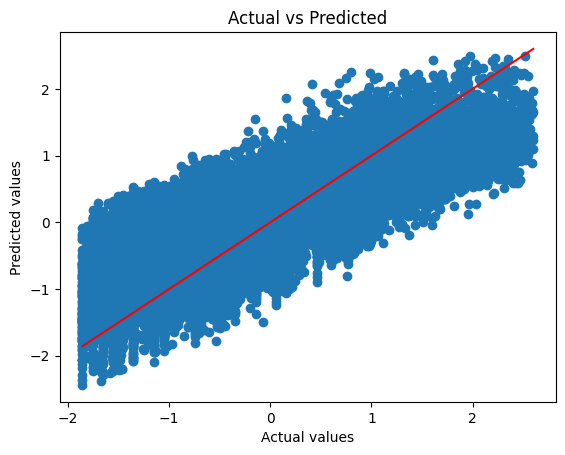

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red') #ideal line

plt.show()

Here we can see more clearly why our models is not that much correct. If our model was perfect, all the points must have been over the red line. We can see that this is not our case.

In this plot, we can see that there is a clear correlation since the points have a diagonal tendency so the model learns the relation quite good. However, all the points are far from the red line which means there is a lot of difference between the predicted and real values.

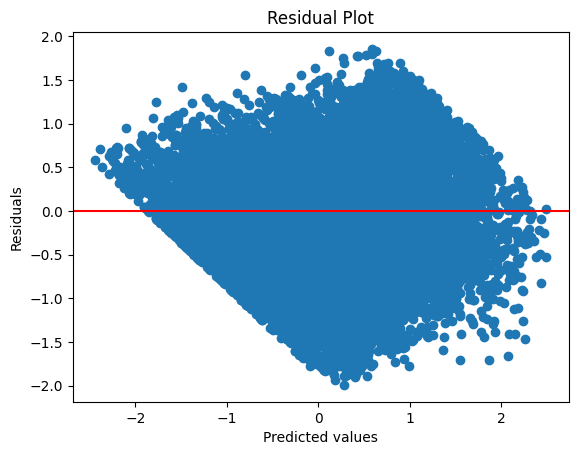

In [33]:
res = y_test - y_pred

plt.scatter(y_pred, res)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Here we can observe a residual plot, where residuals is the difference between y test and y predicted. We can see that the variability is not constant but we can see geometric patterns. This means it is not a good model since in a good one, this plot must show like noise.

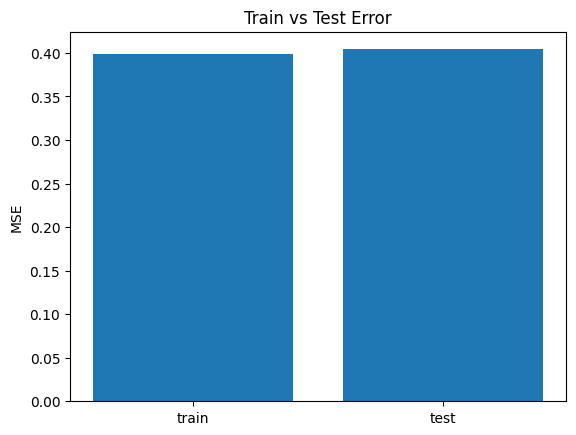

In [34]:
plt.bar(["train", "test"], [mean_error, train_mse])
plt.ylabel("MSE")
plt.title("Train vs Test Error")
plt.show()

We can see both predictions are similar so we can say there is no underfitting or overfitting.